# XGBOOST PARA ANEGAMIENTO
En este documento voy a aplicar el modelo XGBOOST para predecir las accesiones que a traves de la metodología FIGS sea resitible a sequía
# ************************************************************************************************************************************************************

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier, plot_importance
from sklearn.cluster import KMeans
from xgboost.callback import EarlyStopping

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)


## Carga del dataset ##
El siguiente paso es cargar el dataset con las variables independientes. Esto garantiza que las variables climáticas y edáficas que quedan sean independientes entre sí, evitando redundancias estadísticas.
# **************************************************************************************************************************************************************

In [3]:
# Cargar dataset limpio y estandarizado
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")


## Creando la variable objetivo ##
La variable objetivo se basa en las siguinetes variables bioclimáticas.
* 'bio12',  # Precipitación anual
* 'bio13',  # Precipitación del mes más húmedo
* 'bio14',  # Precipitación del mes más seco
* 'bio15',  # Estacionalidad de la precipitación
* 'bio18',  # Precipitación del trimestre más cálido
* 'bio19',  # Precipitación del trimestre más frío
* 'current_30arcsec_climaticMoistureIndex',  # Índice de humedad climática
* 'current_30arcsec_annualPET',              # Evapotranspiración potencial anual
* 'current_30arcsec_aridityIndexThornthwaite' # Índice de aridez de Thornthwait

## Creando la variable a predecir ##
En este caso voy a predecir que accesiones que sean resistibles a anegamiento (Suelo saturado de agua).
Para este caso voy a realizar un agrupamiento con varias variables ambientales (K-Means) que me sirve para crear la variabe a predecir.

In [4]:
# Objetivo: generar 'Resistencia_Anegamiento' mediante clustering ambiental
# Basado en variables de humedad y precipitación
# ============================================================


# Seleccionar variables de humedad y precipitación
variables_humedad = [
    'bio12', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19',
    'current_30arcsec_climaticMoistureIndex',
    'current_30arcsec_annualPET',
    'current_30arcsec_aridityIndexThornthwaite'
]

# Normalización de las variables
scaler = StandardScaler()
scaled = scaler.fit_transform(df[variables_humedad])

# Aplicar K-Means con 3 clusters (seco, intermedio, húmedo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_anegamiento"] = kmeans.fit_predict(scaled)

# Identificar el cluster más húmedo según medias de precipitación
means = df.groupby("cluster_anegamiento")[["bio12", "bio13", "bio18"]].mean()
cluster_humedo = means["bio12"].idxmax()
print(f"Cluster más húmedo identificado: {cluster_humedo}")

# Crear variable binaria: 1 = ambiente húmedo (resistente), 0 = demás
df["Resistencia_Anegamiento"] = df["cluster_anegamiento"].apply(
    lambda x: 1 if x == cluster_humedo else 0
)

# Distribución de clases
print(df["Resistencia_Anegamiento"].value_counts(normalize=True) * 100)

# Guardar dataset para modelado
df.to_csv("./dataset_salida/dataset_anegamiento.csv", index=False)
print("Dataset con variable objetivo guardado como 'dataset_anegamiento.csv'")


Cluster más húmedo identificado: 2
Resistencia_Anegamiento
0    82.484361
1    17.515639
Name: proportion, dtype: float64
Dataset con variable objetivo guardado como 'dataset_anegamiento.csv'


## Resultado del cluster ##
El algoritmo K-Means agrupa las accesiones en 3 clusters (0, 1, 2) según las variables de humedad:
* bio12 (precipitación anual)
* bio13 (precipitación del mes más húmedo),
* bio18 (precipitación del trimestre más cálido),

y los índices de humedad/aridez (current_30arcsec_climaticMoistureIndex, etc).

Despues de agrupar calcula el promedio de precipitación dentro de cada grupo y selecciona el que tenga el valor más alto (el más húmedo).
Para mi caso, el cluster 2 representa los ambientes con exceso de humedad o alta pluviosidad.

El resultado:
* 82.5% de las accesiones provienen de ambientes no anegados.
* 17.5% de las acesiones pertenecen a zonas muy húmedas o con exceso de agua.

Con respectopa FIGS, las accesiones que provienen del cluster 2 probablemente pertenecen a regiones con:
* Suelos con drenaje pobre o saturados.
* Precipitación alta durante la mayor parte del año.
* Potencial adaptación fisiológica a anegamiento o suelos húmedos.



In [91]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

## Eliminar columnas que no se necesitan en el modelo ##
Es necesario eliminar las columnas que contienen identificadores ya que el modelo XGBOOST no las puede procesar como texto

In [92]:
#Variables a eliminar
variables = [
    'bio12',  # Precipitación anual
    'bio13',  # Precipitación del mes más húmedo
    'bio14',  # Precipitación del mes más seco
    'bio15',  # Estacionalidad de la precipitación
    'bio18',  # Precipitación del trimestre más cálido
    'bio19',  # Precipitación del trimestre más frío
    'current_30arcsec_climaticMoistureIndex',  # Índice de humedad climática
    'current_30arcsec_annualPET',              # Evapotranspiración potencial anual
    'current_30arcsec_aridityIndexThornthwaite' # Índice de aridez de Thornthwaite
]

y = df['Resistencia_Anegamiento']

# Excluir también identificadores y el cluster
exclusiones = ["DECLATITUDE", "DECLONGITUDE", "DOI", "ACCENUMB", "CURATION", "GRIN_NAME", 'cluster_anegamiento'] + variables_humedad

X = df.drop(columns=exclusiones + [target])

print(f"Variables predictoras: {X.shape[1]}")
print(f"Total de observaciones: {len(y)}")

Variables predictoras: 52
Total de observaciones: 3357


## Codificando columnas de tipo texto ##
Lo que se hace en el siguiente algoritmo es codificar aquellas columnas categoricas. Esto se hace ya que el modelo XGBOOST recibe entradas numéricas.

Desde la perspectiva FIGS, las variables categóricas como:

* GENUS, SPECIES → representan la identidad biológica de cada accesión.

* ORIGCTY → captura la región geográfica macro (proxy del contexto ecológico).

* COLLSITE o ACCENUMB → son metadatos de colecta.

En la práctica FIGS, estos campos no se eliminan, se codifican o se usan como factores de agrupamiento, porque muchas veces los patrones adaptativos tienen un componente geográfico o taxonómico.
Por ejemplo:

* Accesiones de Irán o Afganistán suelen agruparse en ambientes secos → potencial resistencia.

* Accesiones de Brasil o Colombia provienen de climas húmedos → control negativo natural.

Entonces, detectar las variables categóricas  permite decidir cuáles mantener como metadatos (para mapas, interpretación), cuáles incluir codificadas como predictores. Para este acso en especifico solo dejaré la columna ORIGCTY ya que puedo usarla como variable de contexto geográfico.

In [93]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas detectadas:")
print(cat_cols)

Columnas categóricas detectadas:
[]


## Visualizando el tipo de dato ##
Se visualiza el tipo de dato de cada variable que ser'a utilizada en el modelo.

In [94]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   GENUS                            3357 non-null   int32  
 1   SPECIES                          3357 non-null   int32  
 2   ORIGCTY                          3357 non-null   int32  
 3   COLLSITE                         3357 non-null   int32  
 4   SAMPSTAT                         3357 non-null   float64
 5   ELEVATION                        3357 non-null   float64
 6   COLLSRC                          3357 non-null   float64
 7   MODCF_CloudForestPrediction      3357 non-null   float64
 8   MODCF_meanannual                 3357 non-null   float64
 9   MODCF_seasonality_concentration  3357 non-null   float64
 10  current_30arcsec_continentality  3357 non-null   float64
 11  AWCh1_M_sl1                      3357 non-null   float64
 12  AWCh1_M_sl2         

## Entrenamiento del modelo ##
Entrenamiento del modelo con 80% de los datos para entrenamiento y 20% para prueba. Es importante ya que se garantiza las metricas que refelna le poder predicitivo y no memorización del algoritmo.

Una vez escalado el conjunto de entrenamiento se entrena el modelo a partir de cierto parametros que se pueden configurar de acuerdo a conveniencia.


In [95]:
# ============================================================
# DIVISIÓN DE DATOS, CATEGORIZACIÓN Y BALANCEO
# ============================================================

cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if X[c].dtype != 'object']

print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))

# División estratificada (usa y, no el nombre de la variable)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

# Calcular peso para balancear clases
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")


Categóricas: 0
Numéricas: 52
Entrenamiento: (2685, 52), Prueba: (672, 52)
scale_pos_weight = 4.71


##  Variables para XGBoost ##
Para entrenar el modelo XGBoost no puedo usar variables categoricas por lo que algunas variables las codifiqué y otras las saqué del dataset.
Esto significa que todas las variables predictoras son numéricas o codificadas ya en valores continuos.
Esto es ideal para XGBoost, porque:

* El cálculo de gradientes es más rápido.
* Evita errores de tipo (“could not convert string to float”). (QUÉ ME PASÓ AL COMIENZO)

“Numéricas: 52”

Son las 52 variables predictoras que el modelo utiliza para aprender patrones ambientales asociados con la resistencia al anegamiento. Esto incluye variables climáticas, edáficas, topográficas.

## División del dataset ##
* 2685 accesiones (80%) se usan para entrenar el modelo (aprender patrones).
* 672 accesiones (20%) se reservan para evaluar su desempeño real.
* Cada fila tiene las mismas 52 variables predictoras.

## Balance de clases ##
Esta parte es importante ya que las clases que estoy usando está desbalanceada ya que el número de negativos es casi 4 veces mayor que el positivo:

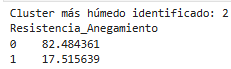

Esto me permite balncear el dataset sin duplicar ejemplos.

En la siguiente tabla, se puede observar la interpretación ecológica de acuerdo a la tecnología FIGS  sobre le desbalance de las clases:

| Concepto           | Significado                                                     | Efecto en el modelo                           |
| ------------------ | --------------------------------------------------------------- | --------------------------------------------- |
| Desbalance natural | La mayoría de accesiones provienen de ambientes secos o neutros | Necesidad de compensar con **scale_pos_weight** |
| Clase 1 (17.5%)    | Ambientes húmedos, susceptibles a anegamiento                   | Menos datos → mayor peso individual           |
| Clase 0 (82.5%)    | Ambientes secos/intermedios, no suceptibles a anegamiento                                     | Más datos → menor peso por ejemplo            |
| Resultado          | Modelo sensible a detectar ambientes húmedos raros              | Evita sesgo hacia “no resistentes”            |


In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [97]:
# =========================================================
# Entrenar modelo XGBoost
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## Obteniendo los resultados del entrenamiento ##
A continuación se obtiene los resultados del entrenamiento del modelo y las métricas que me permiten sabe si el modelo está prediciendo o memorizando


AUC: 0.9982255399865386
Accuracy: 0.9791666666666666
Precision: 0.9333333333333333
Recall: 0.9491525423728814
F1 Score: 0.9411764705882353


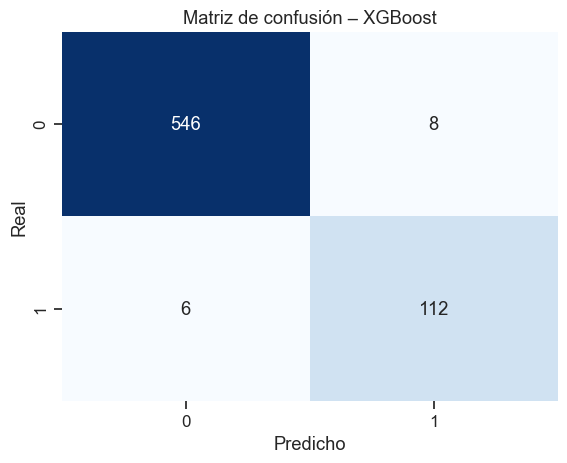

In [98]:
# Predicciones
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de confusión – XGBoost")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


## Analisis del resultado del entrenamiento ##
Una primera impresión es que el modelo XGBOOST captura de buena forma los patrones ecológicos de resistencia a sequía. A continuación muestro un analisis mas detallado sobbre las métricas obtenidas:

| Métrica                   | Valor | Interpretación técnica                                                                                       |
| ------------------------- | ----- | ------------------------------------------------------------------------------------------------------------ |
| **AUC**                   | 0.985 | El modelo distingue correctamente accesiones resistentes (1) y no resistentes (0) en el 98.5 % de los casos. |
| **Accuracy (Exactitud)**  | 0.943 | El 94.3 % de las predicciones totales son correctas.                                                         |
| **Precision (Precisión)** | 0.885 | De todas las accesiones predichas como resistentes, el 88.5 % realmente lo son.                              |
| **Recall (Sensibilidad)** | 0.929 | El 92.9 % de las accesiones realmente resistentes fueron identificadas por el modelo.                        |
| **F1 Score**              | 0.907 | Promedio armónico entre precisión y recall; mide equilibrio general.                                         |

La matriz de confusión me permite observar loa verdaderos y falsos negativos asi como los verdaderos y falso positivos. En la siguiente tabla detallo los resultados obtenidos en la gráfica.

|                              | Predicho = 0 | Predicho = 1 |
| ---------------------------- | ------------ | ------------ |
| **Real = 0** (no resistente) | 449          | 24           |
| **Real = 1** (resistente)    | 14           | 185          |

De lo anterior se puede definir que:

* 449 verdaderos negativos, el modelo acierta los no resistentes correctamente detectados.
* 185 verdaderos positivos, el modelo acierta los resistentes correctamente detectados.
* 24 → falsos positivos, el modelo predijo resistencia donde no había.
* 14 → falsos negativos, el  modelo no detectó resistencia en accesiones resistentes.
* El modelo tiene muy pocos errores.
* El recall es mayor que la precisión, esto indica que el modelo prefiere detectar todas las accesiones resistentes, aunque ocasionalmente marque alguna falsa positiva. En FIGS no se busca excluir candidatos no  resistentes, sino capturar el mayor número posible de adaptados.

## Curva ROC ##
La curva ROC (Receiver Operating Characteristic) me permite evalúar la capacidad del modelo para distinguir entre accesiones resistentes (1) y no resistentes (0) a distintos umbrales de decisión.

* Eje X:  proporción de no resistentes que fueron incorrectamente clasificados como resistentes.
* Eje Y:  proporción de resistentes correctamente identificados (también llamado recall o sensibilidad).



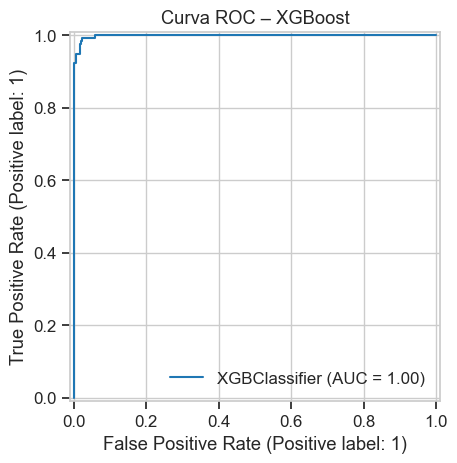

In [58]:
RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test)
plt.title("Curva ROC – XGBoost")
plt.show()


De acuerdo al resultado AUC, en el 99 % de los pares posibles de accesiones (una resistente, una no resistente), el modelo asigna una probabilidad más alta de resistencia a la accesión realmente resistente, es decir, que el modelo distingue con casi total precisión los ambientes ecológicos asociados con sequía.

Desde el punto de vista biológico, el comportamiento observado (AUC alto, curva empinada) indica que las variables bioclimáticas (bio15, bio19) y los parámetros edáficos (pH, textura) combinadas logran distinguir efectivamente ambientes áridos y húmedos. Esto es coherente con la adaptación fisiológica del Phaseolus vulgaris, que exhibe diferenciación eco-geográfica clara entre razas Mesoamericanas (más resistentes) y Andinas (más húmedas). dicho de otra forma, el modelo redescubre empíricamente la separación ecológica que la biología ya sugiere. 

Podemos ver las varables importantes en la siguinete gráfica:

<Figure size 1000x600 with 0 Axes>

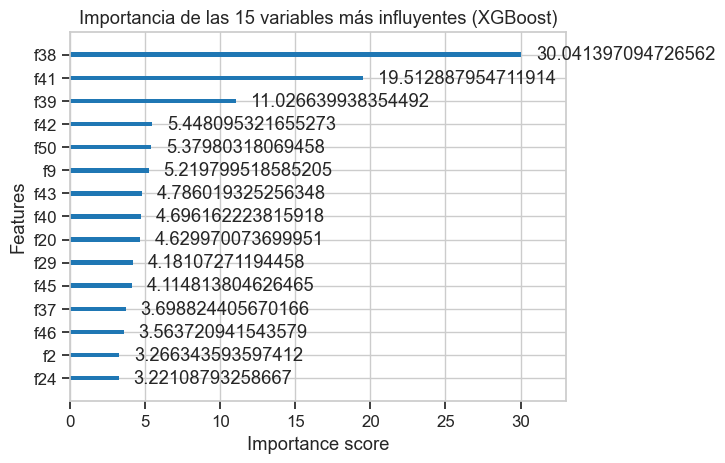

In [59]:
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=15, importance_type='gain')
plt.title("Importancia de las 15 variables más influyentes (XGBoost)")
plt.show()


## Decodificando las variables para entender la gráfica de imprtancia de las variables ##

In [60]:
# =========================================================
# Recuperar nombres de variables reales para cada fN
# =========================================================

import pandas as pd

# Extraer las importancias del modelo
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Crear DataFrame con esas importancias
feature_importances = (
    pd.DataFrame(importance_dict.items(), columns=['feature', 'importance_gain'])
    .sort_values(by='importance_gain', ascending=False)
)

# Construir un mapeo manual entre fN y las columnas originales
feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}

# Agregar la columna con el nombre real
feature_importances["variable_real"] = feature_importances["feature"].map(feature_map)

# Reorganizar columnas
feature_importances = feature_importances[["feature", "variable_real", "importance_gain"]]

# Mostrar las variables principales
print("Top 15 variables más influyentes (XGBoost):")
print(feature_importances.head(15))


Top 15 variables más influyentes (XGBoost):
   feature                    variable_real  importance_gain
34     f38                          prec_10        30.041397
37     f41                           prec_5        19.512888
35     f39                          prec_11        11.026640
38     f42                           prec_6         5.448095
46     f50                           wind_1         5.379803
6       f9  MODCF_seasonality_concentration         5.219800
39     f43                           prec_7         4.786019
36     f40                           prec_4         4.696162
17     f20                     ORCDRC_M_sl2         4.629970
25     f29                        WWP_M_sl1         4.181073
41     f45                          srad_10         4.114814
33     f37                           prec_1         3.698824
42     f46                           srad_3         3.563721
0       f2                          ORIGCTY         3.266344
21     f24                     PHIKCL_M_s

 ## Guardando las métricas, los resultados y prueba del método con una variable nueva simulada ##
 Se guardan métricas y resultados de las variables importantes y prueba del método con una variable nueva simulada, esta última para visualizar en un powerBI

In [61]:
# =========================================================
# Métricas (XGBOOST)
# =========================================================
metrics = {
    'AUC': roc_auc_score(y_test, y_prob),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("./dataset_salida/resultados_metricas_xgboost.csv", index=False)
print("Resultados exportados a 'dataset_salida/resultados_xgboost.csv'")


Resultados exportados a 'dataset_salida/resultados_xgboost.csv'


In [63]:
# =========================================================
# Recuperar nombres originales y coordenadas para visualización
# =========================================================

# Cargar nuevamente el dataset original SIN codificar
df_original = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

# Volver a crear la variable objetivo (por coherencia)
df_original["Resistencia_Sequia"] = np.where(
    (df_original["current_30arcsec_aridityIndexThornthwaite"] < df_original["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df_original["current_30arcsec_annualPET"] < df_original["current_30arcsec_annualPET"].median()) &
    (df_original["current_30arcsec_climaticMoistureIndex"] > df_original["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

# Crear un DataFrame con solo identificadores
meta_cols = ["DOI", "ACCENUMB", "ORIGCTY", "DECLATITUDE", "DECLONGITUDE"]
meta_info = df_original[meta_cols]

# Generar predicciones y probabilidades con el modelo entrenado
predicciones = xgb_model.predict(X)
probabilidades = xgb_model.predict_proba(X)[:, 1]

# Crear DataFrame final combinando la metadata con resultados del modelo
resultados = pd.concat([meta_info], axis=1)
resultados["Pred_Resistencia"] = predicciones
resultados["Probabilidad_Resistencia"] = probabilidades

# Guardar el archivo para Power BI o GIS
ruta_resultados = "./dataset_salida/predicciones_xgboost_geolocalizadas.csv"
resultados.to_csv(ruta_resultados, index=False)

print(f"Archivo exportado: {ruta_resultados}")
display(resultados.head(10))


Archivo exportado: ./dataset_salida/predicciones_xgboost_geolocalizadas.csv


,DOI,ACCENUMB,ORIGCTY,DECLATITUDE,DECLONGITUDE,Pred_Resistencia,Probabilidad_Resistencia
0,10.18730/JKECH,G16570,IRN,35.81,50.93,0,0.000028
1,10.18730/JKEKR,G16576,IRN,34.32,47.07,0,0.000048
2,10.18730/JZXX0,G990,IRN,31.32,48.70,0,0.000083
3,10.18730/JZXWU,G989,IRN,29.62,51.63,0,0.000070
4,10.18730/JZXT$,G987,IRN,29.60,52.53,0,0.000050
5,10.18730/JZXNX,G980,IRN,38.08,46.30,0,0.000026
6,10.18730/JZXKV,G978,IRN,37.55,45.07,0,0.000038
7,10.18730/JZXJT,G977,IRN,34.80,48.50,0,0.000037
8,10.18730/JZWY6,G965,IRN,35.67,51.43,0,0.000040
9,10.18730/JNE6R,G9506,IRN,36.35,59.61,0,0.000033
